In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('boat_data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9888 entries, 0 to 9887
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Price                        9888 non-null   object 
 1   Boat Type                    9888 non-null   object 
 2   Manufacturer                 8550 non-null   object 
 3   Type                         9882 non-null   object 
 4   Year Built                   9888 non-null   int64  
 5   Length                       9879 non-null   float64
 6   Width                        9832 non-null   float64
 7   Material                     8139 non-null   object 
 8   Location                     9852 non-null   object 
 9   Number of views last 7 days  9888 non-null   int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 772.6+ KB


In [4]:
df.head()

,Price,Boat Type,Manufacturer,Type,Year Built,Length,Width,Material,Location,Number of views last 7 days
0,CHF 3337,Motor Yacht,Rigiflex power boats,new boat from stock,2017,4.00,1.90,NaN,Switzerland Â» Lake Geneva Â» VÃ©senaz,226
1,EUR 3490,Center console boat,Terhi power boats,new boat from stock,2020,4.00,1.50,Thermoplastic,Germany Â» BÃ¶nningstedt,75
2,CHF 3770,Sport Boat,Marine power boats,new boat from stock,0,3.69,1.42,Aluminium,Switzerland Â» Lake of Zurich Â» StÃ¤fa ZH,124
3,DKK 25900,Sport Boat,Pioner power boats,new boat from stock,2020,3.00,1.00,NaN,Denmark Â» Svendborg,64
4,EUR 3399,Fishing Boat,Linder power boats,new boat from stock,2019,3.55,1.46,Aluminium,Germany Â» Bayern Â» MÃ¼nchen,58


In [5]:
df.isnull().sum()

Price                             0
Boat Type                         0
Manufacturer                   1338
Type                              6
Year Built                        0
Length                            9
Width                            56
Material                       1749
Location                         36
Number of views last 7 days       0
dtype: int64

In [6]:
col = df.columns

In [7]:
for i in col:
    if df[i].dtypes=='object':
        df[i] = df[i].fillna(df[i].mode()[0])
    else:
        df[i] = df[i].fillna(df[i].mean())

In [8]:
df.isnull().sum()

Price                          0
Boat Type                      0
Manufacturer                   0
Type                           0
Year Built                     0
Length                         0
Width                          0
Material                       0
Location                       0
Number of views last 7 days    0
dtype: int64

In [9]:
df[['currency','Price']]= df['Price'].str.split(' ', 1, expand=True)

In [10]:
def pd(Price,currency):
    if currency=='EUR':
        return int(Price) * 1.11
    elif currency=='CHF':
        return int(Price) * 1.13
    elif currency=='DKK':
        return int(Price) * 0.15
    elif currency=='Â£':
        return int(Price) * 1.25

In [11]:
df['Price'] = df.apply(lambda x: pd(x.Price, x.currency), axis=1)

In [12]:
df.head()

,Price,Boat Type,Manufacturer,Type,Year Built,Length,Width,Material,Location,Number of views last 7 days,currency
0,3770.81,Motor Yacht,Rigiflex power boats,new boat from stock,2017,4.00,1.90,GRP,Switzerland Â» Lake Geneva Â» VÃ©senaz,226,CHF
1,3873.90,Center console boat,Terhi power boats,new boat from stock,2020,4.00,1.50,Thermoplastic,Germany Â» BÃ¶nningstedt,75,EUR
2,4260.10,Sport Boat,Marine power boats,new boat from stock,0,3.69,1.42,Aluminium,Switzerland Â» Lake of Zurich Â» StÃ¤fa ZH,124,CHF
3,3885.00,Sport Boat,Pioner power boats,new boat from stock,2020,3.00,1.00,GRP,Denmark Â» Svendborg,64,DKK
4,3772.89,Fishing Boat,Linder power boats,new boat from stock,2019,3.55,1.46,Aluminium,Germany Â» Bayern Â» MÃ¼nchen,58,EUR


In [13]:
df = df.drop(['Location', 'currency'], axis=1)

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [15]:
col = df.columns

In [16]:
for i in col:
    if df[i].dtype=='object':
        df[i] = le.fit_transform(df[i])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9888 entries, 0 to 9887
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Price                        9888 non-null   float64
 1   Boat Type                    9888 non-null   int32  
 2   Manufacturer                 9888 non-null   int32  
 3   Type                         9888 non-null   int32  
 4   Year Built                   9888 non-null   int64  
 5   Length                       9888 non-null   float64
 6   Width                        9888 non-null   float64
 7   Material                     9888 non-null   int32  
 8   Number of views last 7 days  9888 non-null   int64  
dtypes: float64(3), int32(4), int64(2)
memory usage: 540.9 KB


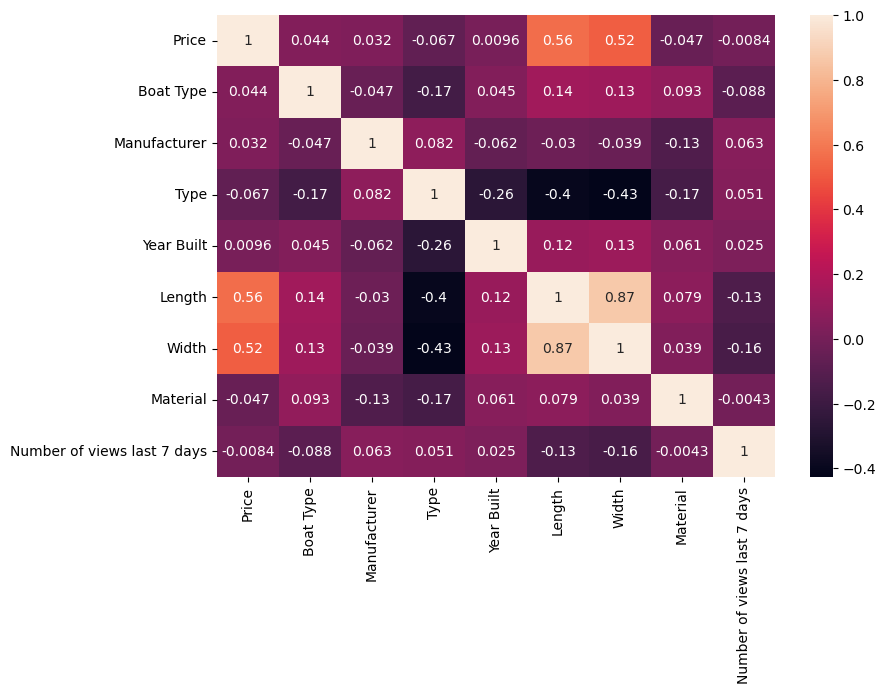

In [18]:
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [19]:
y = df.loc[ : , 'Price']

In [20]:
x = df.iloc[ : , 1:]

In [21]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.feature_selection import RFE

In [22]:
rfr = RFE(RandomForestRegressor())

In [23]:
rfr.fit(x,y)

RFE(estimator=RandomForestRegressor())

In [24]:
rfr.ranking_

array([4, 3, 1, 1, 1, 1, 5, 2])

In [25]:
rfr.n_features_

4

In [26]:
x = rfr.transform(x)

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [29]:
rfor = RandomForestRegressor()

In [30]:
rfor.fit(x_train,y_train)

RandomForestRegressor()

In [31]:
y_pred = rfor.predict(x_test)

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [33]:
r2_score(y_test, y_pred)

0.9097200241927474

In [34]:
mean_squared_error(y_test, y_pred)

112501435100.86792

In [35]:
mean_absolute_error(y_test, y_pred)

87393.63418131159